In [ ]:
!pip install kaggle


In [ ]:
#VIETNAMESE BANKNOTES REGCONITION
from google.colab import files
uploaded = files.upload()


Saving archive (3).zip to archive (3) (1).zip


In [ ]:
import zipfile
import os

zip_file = '/content/archive (3).zip'
extract_folder = '/content/vietnamese_banknotes/'

# Giải nén
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)


In [ ]:
import os

# Kiểm tra cấu trúc thư mục
dataset_dir = '/content/vietnamese_banknotes/'
for subdir, dirs, files in os.walk(dataset_dir):
    print(subdir, " contains ", len(files), " files")



/content/vietnamese_banknotes/  contains  0  files
/content/vietnamese_banknotes/dataset  contains  1  files
/content/vietnamese_banknotes/dataset/500000  contains  250  files
/content/vietnamese_banknotes/dataset/002000  contains  250  files
/content/vietnamese_banknotes/dataset/200000  contains  250  files
/content/vietnamese_banknotes/dataset/000500  contains  250  files
/content/vietnamese_banknotes/dataset/000200  contains  250  files
/content/vietnamese_banknotes/dataset/000000  contains  250  files
/content/vietnamese_banknotes/dataset/010000  contains  250  files
/content/vietnamese_banknotes/dataset/001000  contains  250  files
/content/vietnamese_banknotes/dataset/100000  contains  250  files
/content/vietnamese_banknotes/dataset/005000  contains  154  files
/content/vietnamese_banknotes/dataset/020000  contains  154  files
/content/vietnamese_banknotes/dataset/050000  contains  154  files


In [ ]:
# Đường dẫn đến thư mục chứa dữ liệu
dataset_dir = '/content/vietnamese_banknotes/dataset/'

# Lấy tên các lớp (mệnh giá tiền) từ tên các thư mục con
class_names = os.listdir(dataset_dir)

# Danh sách chứa ảnh và nhãn
images = []
labels = []

# Duyệt qua các thư mục mệnh giá tiền
for class_name in class_names:
    class_folder = os.path.join(dataset_dir, class_name)

    # Kiểm tra nếu là thư mục
    if os.path.isdir(class_folder):
        for filename in os.listdir(class_folder):
            file_path = os.path.join(class_folder, filename)

            # Đọc và tiền xử lý ảnh
            image = load_img(file_path, target_size=(64, 64))  # Đổi kích thước ảnh
            image = img_to_array(image)  # Chuyển đổi ảnh thành mảng
            images.append(image)
            labels.append(class_name)  # Thêm nhãn mệnh giá tiền

# Chuyển đổi danh sách ảnh thành mảng numpy
X = np.array(images)
y = np.array(labels)

# Chuẩn hóa dữ liệu ảnh (chia giá trị pixel cho 255 để có giá trị từ 0 đến 1)
X = X.astype('float32') / 255.0

# Chuyển nhãn thành dạng số
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Chuyển nhãn thành dạng one-hot
y = to_categorical(y, num_classes=len(class_names))




In [ ]:
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.optimizers import Adam

# Chia dữ liệu thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Sequential()

# Flatten ảnh đầu vào (64x64x3) thành vector 1D
model.add(Flatten(input_shape=(64, 64, 3)))
model.add(Dense(128, activation='relu'))
# Thêm lớp đầu ra với số lượng lớp tương ứng với số mệnh giá tiền
model.add(Dense(len(class_names), activation='softmax'))

# Biên dịch mô hình
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])




/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.3045 - loss: 1.7066 - val_accuracy: 0.2431 - val_loss: 1.8996
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2880 - loss: 1.7496 - val_accuracy: 0.2910 - val_loss: 1.8605
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3178 - loss: 1.7020 - val_accuracy: 0.2947 - val_loss: 1.8601
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3246 - loss: 1.6967 - val_accuracy: 0.2928 - val_loss: 1.8727
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3203 - loss: 1.7226 - val_accuracy: 0.3020 - val_loss: 1.9122
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3244 - loss: 1.6968 - val_accuracy: 0.2781 - val_loss: 1.8695
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3310 - loss: 1.6756 - val_accuracy: 0.2818 - val_loss: 1.8487
Epoch 8/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3329 - loss: 1.6784 - val_accuracy: 0.2726 - val_loss

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


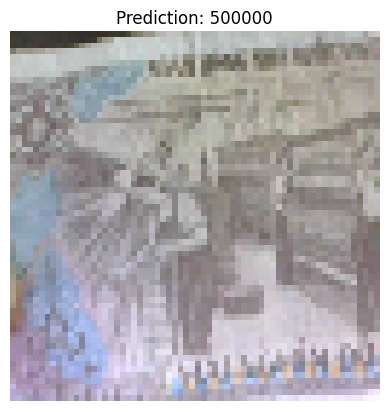

Predicted class: 500000


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Danh sách các mệnh giá tương ứng
class_names = ['000000', '000200', '000500', '001000', '002000',
               '005000', '010000', '020000', '050000', '100000',
               '200000', '500000']

# Chọn một hình ảnh từ tập kiểm tra
sample_image = X_test[5]
sample_label = y_test[0]

# Dự đoán mệnh giá từ ảnh
prediction = model.predict(sample_image.reshape(1, 64, 64, 3))
predicted_class = np.argmax(prediction)

# Hiển thị ảnh và dự đoán
plt.imshow(sample_image)
plt.title(f"Prediction: {class_names[predicted_class]}")
plt.axis('off')
plt.show()

print(f"Predicted class: {class_names[predicted_class]}")


In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [ ]:
#FLOWER REGCONITION

# Load dữ liệu CIFAR-10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Load dữ liệu hoa Oxford
ds_info = tfds.builder('oxford_flowers102').info
class_names = ds_info.features['label'].names

# Tiền xử lý dữ liệu
X_train = X_train.reshape(50000, 32*32*3)
X_train = X_train.astype('float32') / 255
X_test = X_test.reshape(10000, 32*32*3)
X_test = X_test.astype('float32') / 255
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Tạo mô hình
model = Sequential([
    Dense(1024, activation='relu', input_shape=(32*32*3,)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile mô hình
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Huấn luyện mô hình
history = model.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_test, y_test))



Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.2642 - loss: 2.0968 - val_accuracy: 0.3791 - val_loss: 1.7338
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3873 - loss: 1.7004 - val_accuracy: 0.4302 - val_loss: 1.5952
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4225 - loss: 1.6036 - val_accuracy: 0.4476 - val_loss: 1.5428
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4572 - loss: 1.5278 - val_accuracy: 0.4521 - val_loss: 1.5148
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.4710 - loss: 1.4774 - val_accuracy: 0.4526 - val_loss: 1.5352
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4849 - loss: 1.4389 - val_accuracy: 0.4741 - val_loss: 1.4772
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5003 - loss: 1.4004 - val_accuracy: 0.4826 - val_loss: 1.4634
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5115 - loss: 1.3565 - val_accuracy: 0.

In [ ]:
# Import thư viện
import numpy as np
import tensorflow_datasets as tfds
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense # Import Dense layer
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder, StandardScaler
from keras.utils import load_img, img_to_array
from keras.datasets import cifar10


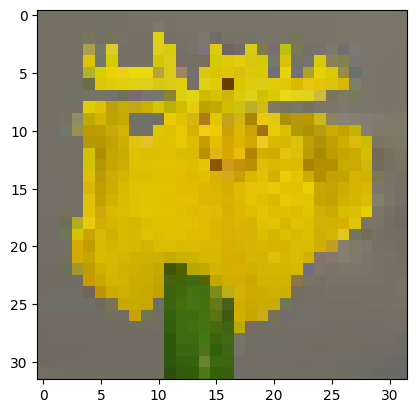

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step
Dự đoán là: 9


In [ ]:
# Dự đoán hình ảnh mới
import matplotlib.pyplot as plt

url = ('/content/HOA IRIS YELLOW.jpg')  # Đường dẫn ảnh
img = load_img(url, target_size=(32, 32))
plt.imshow(img)
plt.show()

img_array = img_to_array(img) / 255
img_flatten = img_array.reshape(1, 32*32*3)
prediction = model.predict(img_flatten)
print('Dự đoán là:', np.argmax(prediction))

In [ ]:
import os
import shutil

# Tạo thư mục .kaggle nếu chưa có
os.makedirs("/root/.kaggle", exist_ok=True)

# Di chuyển tệp kaggle.json vào thư mục .kaggle
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")

# Đặt quyền truy cập cho tệp
os.chmod("/root/.kaggle/kaggle.json", 600)


In [ ]:
!ls /content


drive  Images  LICENSE	sample_data  Urls  vietnamese-foods.zip


Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5000 - loss: 1.2792
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5000 - loss: 6.3052
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5000 - loss: 1.8265
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5000 - loss: 1.0262
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.1839
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5000 - loss: 0.8443
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 1.0000 - loss: 0.0584
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 1.0000 - loss: 0.0189
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 1.0000 - loss: 0.0119
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 1.0000 - loss: 0.0090
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


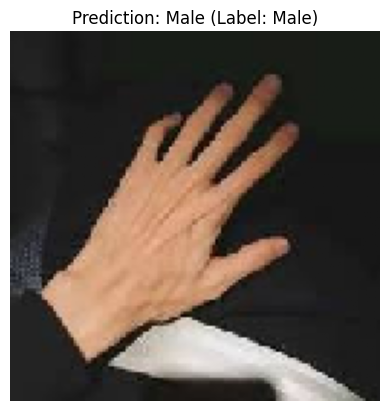

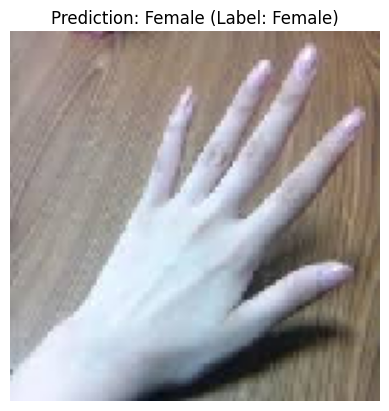

In [ ]:
#PALM
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.preprocessing.image import load_img, img_to_array
from keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# Đường dẫn tới 2 ảnh tay nam và tay nữ
male_hand_image_path = '/content/TAY NAM.jpg'  # Đường dẫn ảnh tay nam
female_hand_image_path = '/content/TAY NỮ.jpg'  # Đường dẫn ảnh tay nữ

# Tiền xử lý ảnh
def preprocess_image(image_path):
    # Tải ảnh và thay đổi kích thước về 128x128
    img = load_img(image_path, target_size=(128, 128))
    img_array = img_to_array(img)  # Chuyển ảnh thành mảng
    img_array = img_array.astype('float32') / 255  # Chuẩn hóa giá trị pixel
    return img_array

# Tiền xử lý các ảnh
male_hand = preprocess_image(male_hand_image_path)
female_hand = preprocess_image(female_hand_image_path)

# Kết hợp ảnh vào một mảng dữ liệu và gán nhãn
X = np.array([male_hand, female_hand])
y = np.array([0, 1])  # Nhãn (0 cho tay nam, 1 cho tay nữ)

# Chuyển nhãn thành dạng one-hot encoding
y = to_categorical(y, num_classes=2)

# Xây dựng mô hình ANN
model = Sequential([
    Flatten(input_shape=(128, 128, 3)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(2, activation='softmax')
])

# Compile mô hình
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Huấn luyện mô hình
history = model.fit(X, y, epochs=10, batch_size=2)

# Kiểm tra mô hình với ảnh tay nam và tay nữ
pred_male = model.predict(np.array([male_hand]))
pred_female = model.predict(np.array([female_hand]))

# Hàm hiển thị ảnh và kết quả dự đoán
def show_image_with_prediction(image, prediction, label):
    plt.imshow(image)
    predicted_label = 'Female' if np.argmax(prediction) == 1 else 'Male'
    plt.title(f"Prediction: {predicted_label} (Label: {label})")
    plt.axis('off')
    plt.show()


show_image_with_prediction(male_hand, pred_male, 'Male')

show_image_with_prediction(female_hand, pred_female, 'Female')


Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.0000e+00 - loss: 53.9291
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4139 - loss: 4.5714 
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1083 - loss: 3.9636     
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5194 - loss: 4.3669     
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8361 - loss: 0.3823 
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5889 - loss: 1.3406 
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8917 - loss: 0.4538 
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8361 - loss: 0.5014 
Epoch 9/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5194 - loss: 0.9685     
Epoch 10/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8361 - loss: 0.4209 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


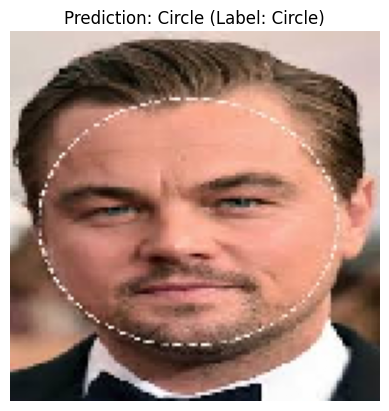

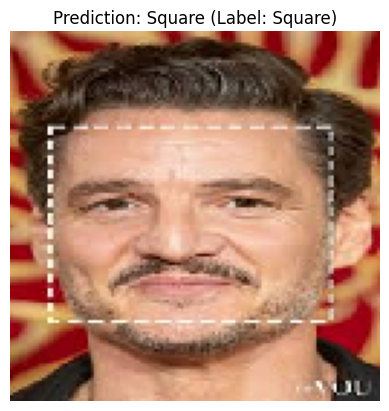

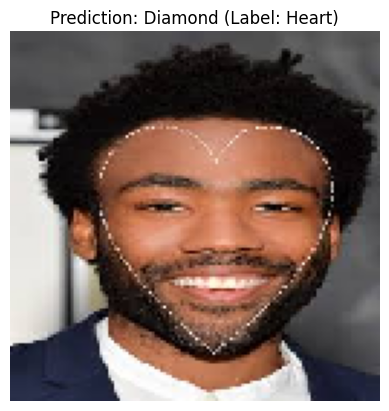

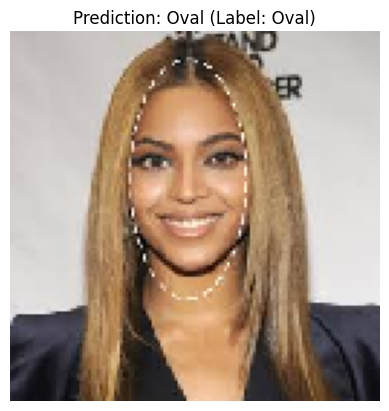

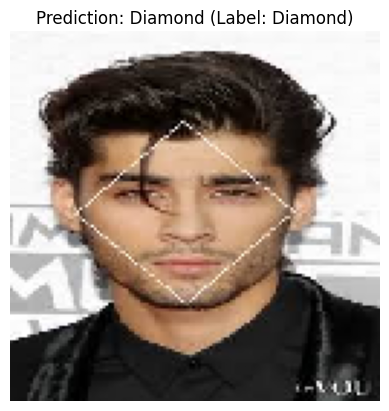

In [ ]:
#FACESHAPE
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.preprocessing.image import load_img, img_to_array
from keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# Đường dẫn tới các ảnh của 5 kiểu gương mặt
circle_image_path = '/content/mat tron.jpg'
square_image_path = '/content/mat vuong.jpg'
heart_image_path = '/content/heart face.jpg'
oval_image_path = '/content/oval.jpg'
diamond_image_path = '/content/kim cuong mat.jpg'

# Tiền xử lý ảnh
def preprocess_image(image_path):
    img = load_img(image_path, target_size=(128, 128))  # Tải ảnh và thay đổi kích thước
    img_array = img_to_array(img)  # Chuyển ảnh thành mảng
    img_array = img_array.astype('float32') / 255  # Chuẩn hóa giá trị pixel
    return img_array

# Tiền xử lý các ảnh
circle_face = preprocess_image(circle_image_path)
square_face = preprocess_image(square_image_path)
heart_face = preprocess_image(heart_image_path)
oval_face = preprocess_image(oval_image_path)
diamond_face = preprocess_image(diamond_image_path)

# Kết hợp ảnh vào một mảng dữ liệu và gán nhãn
X = np.array([circle_face, square_face, heart_face, oval_face, diamond_face])  # Dữ liệu (5 kiểu gương mặt)
y = np.array([0, 1, 2, 3, 4])  # Nhãn (0: Circle, 1: Square, 2: Heart, 3: Oval, 4: Diamond)

# Chuyển nhãn thành dạng one-hot encoding
y = to_categorical(y, num_classes=5)

model = Sequential([
    Flatten(input_shape=(128, 128, 3)),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax')  # 5 lớp cho các hình dạng gương mặt
])


# Compile mô hình
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Huấn luyện mô hình
history = model.fit(X, y, epochs=10, batch_size=1)

# Kiểm tra mô hình với các ảnh gương mặt
pred_circle = model.predict(np.array([circle_face]))
pred_square = model.predict(np.array([square_face]))
pred_heart = model.predict(np.array([heart_face]))
pred_oval = model.predict(np.array([oval_face]))
pred_diamond = model.predict(np.array([diamond_face]))

# Hàm hiển thị ảnh và kết quả dự đoán
def show_image_with_prediction(image, prediction, label):
    plt.imshow(image)
    predicted_label = ['Circle', 'Square', 'Heart', 'Oval', 'Diamond'][np.argmax(prediction)]
    plt.title(f"Prediction: {predicted_label} (Label: {label})")
    plt.axis('off')
    plt.show()

# Hiển thị ảnh và kết quả dự đoán cho từng kiểu gương mặt
show_image_with_prediction(circle_face, pred_circle, 'Circle')
show_image_with_prediction(square_face, pred_square, 'Square')
show_image_with_prediction(heart_face, pred_heart, 'Heart')
show_image_with_prediction(oval_face, pred_oval, 'Oval')
show_image_with_prediction(diamond_face, pred_diamond, 'Diamond')


In [ ]:
from google.colab import files
files.upload()  # Tải file kaggle.json lên Colab


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"tuynlkim","key":"2eadb7a876c80b8b44d4c0f898e3f2b0"}'}

In [ ]:
!pip install kaggle


In [ ]:
!kaggle datasets download -d quandang/vietnamese-foods


Dataset URL: https://www.kaggle.com/datasets/quandang/vietnamese-foods
License(s): CC-BY-NC-SA-4.0


In [ ]:
!unzip vietnamese-foods.zip -d /content/vietnamese-foods/


Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
  inflating: /content/vietnamese-foods/Images/Train/Hu tieu/304.jpg  
  inflating: /content/vietnamese-foods/Images/Train/Hu tieu/305.jpg  
  inflating: /content/vietnamese-foods/Images/Train/Hu tieu/306.jpg  
  inflating: /content/vietnamese-foods/Images/Train/Hu tieu/307.jpg  
  inflating: /content/vietnamese-foods/Images/Train/Hu tieu/309.jpg  
  inflating: /content/vietnamese-foods/Images/Train/Hu tieu/31.jpg  
  inflating: /content/vietnamese-foods/Images/Train/Hu tieu/312.jpg  
  inflating: /content/vietnamese-foods/Images/Train/Hu tieu/313.jpg  
  inflating: /content/vietnamese-foods/Images/Train/Hu tieu/314.jpg  
  inflating: /content/vietnamese-foods/Images/Train/Hu tieu/316.jpg  
  inflating: /content/vietnamese-foods/Images/Train/Hu tieu/317.jpg  
  inflating: /content/vietnamese-foods/Images/Train/Hu tieu/318.jpg  
  inflating: /content/vietnamese-foods/Images/Train/Hu tieu/319.jpg  
  inflating: /content/vietnamese-f

In [ ]:
import os
# Kiểm tra cấu trúc thư mục
data_dir = '/content/vietnamese-foods'
for root, dirs, files in os.walk(data_dir):
    print(f"Thư mục: {root}")
    print(f"Tệp tin: {files[:5]}")  # Liệt kê 5 tệp đầu tiên


Thư mục: /content/vietnamese-foods
Tệp tin: ['LICENSE']
Thư mục: /content/vietnamese-foods/Urls
Tệp tin: ['Mi Quang.txt', 'Banh gio.txt', 'Banh beo.txt', 'Bun dau mam tom.txt', 'Banh khot.txt']
Thư mục: /content/vietnamese-foods/Images
Tệp tin: []
Thư mục: /content/vietnamese-foods/Images/Test
Tệp tin: []
Thư mục: /content/vietnamese-foods/Images/Test/Bun bo Hue
Tệp tin: ['61.jpg', '506.jpg', '1318.jpg', '1332.jpg', '676.jpg']
Thư mục: /content/vietnamese-foods/Images/Test/Bun thit nuong
Tệp tin: ['506.jpg', '187.jpg', '381.jpg', '92.jpg', '523.jpg']
Thư mục: /content/vietnamese-foods/Images/Test/Banh duc
Tệp tin: ['76.jpg', '285.jpg', '433.jpg', '286.jpg', '124.jpg']
Thư mục: /content/vietnamese-foods/Images/Test/Banh trang nuong
Tệp tin: ['61.jpg', '427.jpg', '676.jpg', '790.jpg', '92.jpg']
Thư mục: /content/vietnamese-foods/Images/Test/Banh beo
Tệp tin: ['23.jpg', '187.jpg', '286.jpg', '272.jpg', '245.jpg']
Thư mục: /content/vietnamese-foods/Images/Test/Pho
Tệp tin: ['733.jpg', '76.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

In [ ]:
#FOOD
from keras.preprocessing.image import load_img, img_to_array
import numpy as np

# Đọc và chuẩn hóa ảnh
def preprocess_image(image_path, target_size=(128, 128)):
    img = load_img(image_path, target_size=target_size)  # Thay đổi kích thước ảnh
    img_array = img_to_array(img)  # Chuyển ảnh thành mảng NumPy
    img_array = img_array.astype('float32') / 255  # Chuẩn hóa giá trị pixel
    return img_array


In [ ]:
# Đường dẫn đến dữ liệu
data_path = '/content/vietnamese-foods/Images/Train'

# Chọn 5 món ăn
selected_classes = ['Pho', 'Banh mi', 'Bun thit nuong', 'Goi cuon', 'Com tam']

# Kích thước ảnh chuẩn
img_size = (64, 64)

# Tải ảnh và nhãn
images = []
labels = []

for food_class in selected_classes:
    folder = os.path.join(data_path, food_class)
    for filename in os.listdir(folder)[:30]:  # Dùng tối đa 30 ảnh mỗi lớp
        img_path = os.path.join(folder, filename)
        try:
            img = Image.open(img_path).convert('RGB')
            img = img.resize(img_size)
            img_array = np.array(img) / 255.0  # Chuẩn hóa pixel
            images.append(img_array)
            labels.append(food_class)
        except:
            print(f"Lỗi ảnh: {img_path}")

# Chuyển thành numpy array
X = np.array(images)
y = np.array(labels)

# Mã hóa nhãn
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_encoded = to_categorical(y_encoded)

# Tách train/test
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Reshape ảnh cho ANN
X_train = X_train.reshape(len(X_train), 64*64*3)
X_test = X_test.reshape(len(X_test), 64*64*3)


In [ ]:
# Xây dựng mô hình ANN
model = Sequential([
    Dense(512, activation='relu', input_shape=(64*64*3,)),  # Input là mảng 1 chiều
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(len(selected_classes), activation='softmax')  # 5 lớp
])

# Biên dịch mô hình
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
# Huấn luyện mô hình
history = model.fit(X_train, y_train, epochs=15, batch_size=10, validation_split=0.1)


Epoch 1/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - accuracy: 0.5815 - loss: 1.1402 - val_accuracy: 0.0833 - val_loss: 2.1496
Epoch 2/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6629 - loss: 1.0567 - val_accuracy: 0.3333 - val_loss: 1.5924
Epoch 3/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5854 - loss: 1.0599 - val_accuracy: 0.2500 - val_loss: 1.5761
Epoch 4/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6624 - loss: 0.9895 - val_accuracy: 0.5000 - val_loss: 1.3181
Epoch 5/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7229 - loss: 0.8089 - val_accuracy: 0.1667 - val_loss: 1.9896
Epoch 6/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7643 - loss: 0.6066 - val_accuracy: 0.4167 - val_loss: 1.7923
Epoch 7/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7476 - loss: 0.7150 - val_accuracy: 0.3333 - val_loss: 2.2545
Epoch 8/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8182 - loss: 0.4828 - val_accuracy: 0.1667 - val_los

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


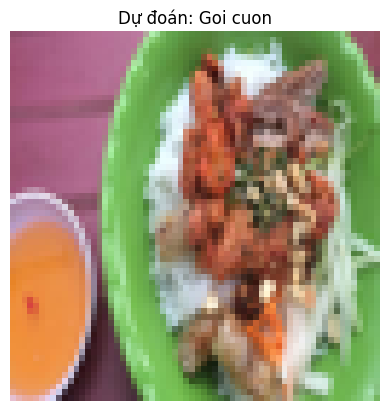

In [ ]:
# Dự đoán trên một ảnh từ tập test
sample_index = 0
sample_image = X_test[sample_index].reshape(1, 64*64*3)
prediction = model.predict(sample_image)
predicted_class = np.argmax(prediction)
predicted_label = label_encoder.inverse_transform([predicted_class])[0]

# Hiển thị ảnh và kết quả dự đoán
plt.imshow(X_test[sample_index].reshape(64, 64, 3))
plt.title(f"Dự đoán: {predicted_label}")
plt.axis('off')
plt.show()
